=== REGRESSION SUMMARY FOR POLICY REVIEW ===
                            OLS Regression Results                            
Dep. Variable:                  churn   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                    nan
Method:                 Least Squares   F-statistic:                       nan
Date:                Wed, 03 Jun 2026   Prob (F-statistic):                nan
Time:                        04:52:19   Log-Likelihood:                 150.32
No. Observations:                   5   AIC:                            -290.6
Df Residuals:                       0   BIC:                            -292.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 5 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: divide by zero encountered in divide
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1795: RuntimeWarning: invalid value encountered in scalar multiply
  return 1 - (np.divide(self.nobs - self.k_constant, self.df_resid)
/usr/local/lib/python3.12/dist-packages/statsmodels/regression/linear_model.py:1717: RuntimeWarning: divide by zero encountered in scalar divide
  return np.dot(wresid, wresid) / self.df_resid


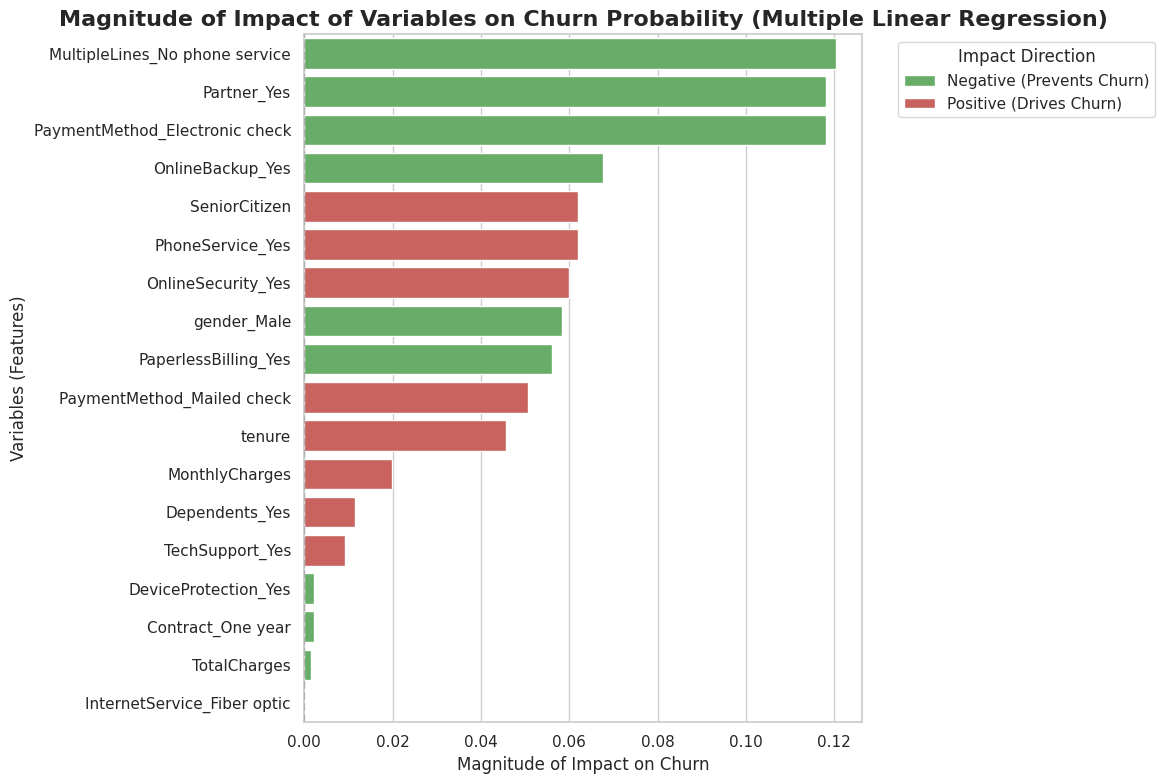

In [14]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the Data
# Uncomment the line below to load your actual CSV file
# df = pd.read_csv('/content/your_dataset.csv')

# --- Placeholder Data mimicking your exact variables ---
# Using a small sample just to make the code runnable out-of-the-box
data = {
    'gender': ['Male', 'Female', 'Male', 'Male', 'Female'],
    'SeniorCitizen': [0, 0, 1, 0, 0],
    'Partner': ['Yes', 'No', 'No', 'No', 'Yes'],
    'Dependents': ['No', 'No', 'No', 'No', 'Yes'],
    'tenure': [1, 34, 2, 45, 2],
    'PhoneService': ['No', 'Yes', 'Yes', 'No', 'Yes'],
    'MultipleLines': ['No phone service', 'No', 'No', 'No phone service', 'No'],
    'InternetService': ['DSL', 'Fiber optic', 'DSL', 'DSL', 'Fiber optic'],
    'OnlineSecurity': ['No', 'Yes', 'Yes', 'Yes', 'No'],
    'OnlineBackup': ['Yes', 'No', 'Yes', 'No', 'No'],
    'DeviceProtection': ['No', 'Yes', 'No', 'Yes', 'No'],
    'TechSupport': ['No', 'No', 'No', 'Yes', 'No'],
    'StreamingTV': ['No', 'No', 'No', 'No', 'No'],
    'StreamingMovies': ['No', 'No', 'No', 'No', 'No'],
    'Contract': ['Month-to-month', 'One year', 'Month-to-month', 'One year', 'Month-to-month'],
    'PaperlessBilling': ['Yes', 'No', 'Yes', 'No', 'Yes'],
    'PaymentMethod': ['Electronic check', 'Mailed check', 'Mailed check', 'Bank transfer (automatic)', 'Electronic check'],
    'MonthlyCharges': [29.85, 56.95, 53.85, 42.30, 70.70],
    'TotalCharges': [29.85, 1889.50, 108.15, 1840.75, 151.65],
    'churn': [0, 0, 1, 0, 1] # 1 = Churned, 0 = Stayed
}
df = pd.DataFrame(data)
# --------------------------------------------------------

# 2. Preprocessing: Convert Categorical Text to Numbers
# Multiple regression CANNOT read text like "Month-to-month" or "Male".
# pd.get_dummies converts these into binary (0 or 1) columns automatically.
df_processed = pd.get_dummies(df, drop_first=True)

# 3. Define X (Features) and y (Target)
y = df_processed['churn']
X = df_processed.drop('churn', axis=1)

# Ensure all data types are float/int for statsmodels
X = X.astype(float)
y = y.astype(float)

# 4. Add Constant for OLS (Generates the 'Intercept')
X = sm.add_constant(X)

# 5. Fit the Multiple Linear Regression Model
model = sm.OLS(y, X).fit()

# Print the comprehensive statistical summary
print("=== REGRESSION SUMMARY FOR POLICY REVIEW ===")
print(model.summary())

# ==========================================
# 6. VISUALIZATION: Coefficient Impact Plot
# ==========================================
# Extracting coefficients and p-values, dropping the 'const' intercept for the plot
results_df = pd.DataFrame({
    'Feature': model.params.index[1:],
    'Coefficient': model.params.values[1:],
    'P-value': model.pvalues.values[1:]
})

# Create a column for absolute coefficient value for sorting and plotting magnitude
results_df['Absolute_Coefficient'] = results_df['Coefficient'].abs()

# Create a column to indicate the direction of the impact (for hue)
results_df['Impact_Direction'] = results_df['Coefficient'].apply(lambda x: 'Positive (Drives Churn)' if x > 0 else 'Negative (Prevents Churn)')

# Sort by the absolute impact
results_df = results_df.sort_values(by='Absolute_Coefficient', ascending=False)

# Plotting setup
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Define a palette for the impact direction
direction_palette = {'Positive (Drives Churn)': '#d9534f', 'Negative (Prevents Churn)': '#5cb85c'}

# Create a bar plot. All bars will extend to the right (positive side).
# Hue indicates the direction of impact, and legend is shown to explain it.
ax = sns.barplot(x='Absolute_Coefficient', y='Feature', hue='Impact_Direction', data=results_df, palette=direction_palette)

# Adding administrative labels and titles
plt.title('Magnitude of Impact of Variables on Churn Probability (Multiple Linear Regression)', fontsize=16, fontweight='bold')
plt.xlabel('Magnitude of Impact on Churn', fontsize=12)
plt.ylabel('Variables (Features)', fontsize=12)

# Adjust legend
ax.legend(title='Impact Direction', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add a vertical line at 0 (though with absolute values, it will always be at the start)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1.5)

plt.tight_layout()
plt.show()

### Actual vs. Predicted Churn Plot

This plot visualizes how well the model's predictions align with the actual churn outcomes. Ideally, all points should fall along the diagonal line, indicating perfect prediction. Due to the very small dataset, this plot might not be representative of the model's true performance on unseen data.

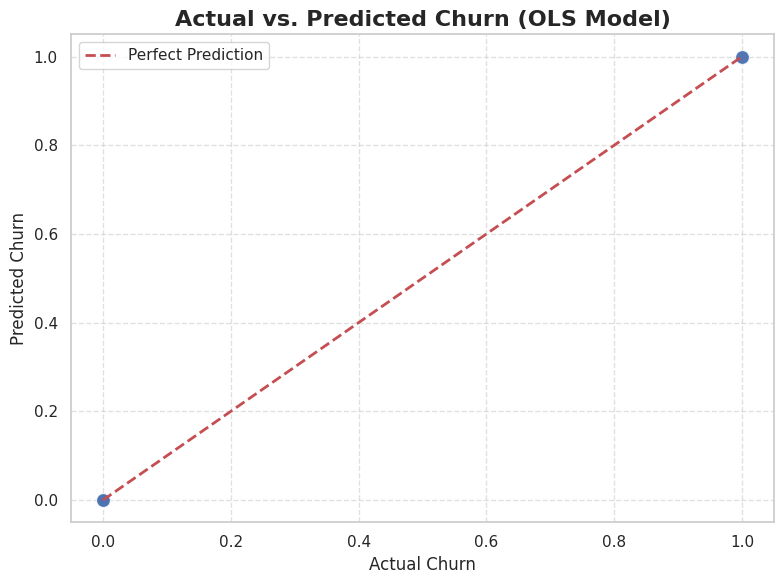

In [15]:
# Get the predicted values from the fitted OLS model
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred, s=100, alpha=0.8)

# Add a line for perfect prediction (y = x)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2, label='Perfect Prediction')

plt.title('Actual vs. Predicted Churn (OLS Model)', fontsize=16, fontweight='bold')
plt.xlabel('Actual Churn', fontsize=12)
plt.ylabel('Predicted Churn', fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Churn Distribution Tree Map

This tree map visualizes the proportion of churned and non-churned customers within different internet service categories. Each rectangle's size is proportional to the count of customers in that segment. Hover over the rectangles to see more details.

**Note**: Due to the extremely small dataset (only 5 observations), this tree map will be very basic and might not offer significant insights. It's primarily for demonstration purposes with the current data.

In [16]:
# Install plotly for interactive visualizations
%pip install plotly

In [17]:
import plotly.express as px

# Prepare data for the treemap: group by InternetService and churn, then count
treemap_data = df.groupby(['InternetService', 'churn']).size().reset_index(name='Count')

# Convert churn to a more descriptive string for better labels
treemap_data['churn_status'] = treemap_data['churn'].map({0: 'No Churn', 1: 'Churn'})

# Create the treemap
fig = px.treemap(
    treemap_data,
    path=[px.Constant("All Customers"), 'InternetService', 'churn_status'],
    values='Count',
    color='churn_status',
    color_discrete_map={'No Churn': 'green', 'Churn': 'red'},
    title='Churn Distribution by Internet Service'
)

fig.update_layout(margin = dict(t=50, l=25, r=25, b=25))
fig.show()

### 1. Overall Churn Distribution

Let's start by looking at the overall proportion of churned vs. non-churned customers in our dataset using a pie chart.

In [18]:
churn_counts = df['churn'].value_counts().reset_index()
churn_counts.columns = ['Churn', 'Count']
churn_counts['Churn'] = churn_counts['Churn'].map({0: 'No Churn', 1: 'Churn'})

fig = px.pie(churn_counts,
             values='Count',
             names='Churn',
             title='Overall Churn Distribution',
             color='Churn',
             color_discrete_map={'No Churn':'green', 'Churn':'red'})
fig.show()

### 2. Churn by Categorical Features

Now, let's explore how churn varies across different categorical features like `gender`, `Partner`, `Dependents`, `PhoneService`, and `InternetService` using count plots. These plots show the number of churned and non-churned customers within each category.

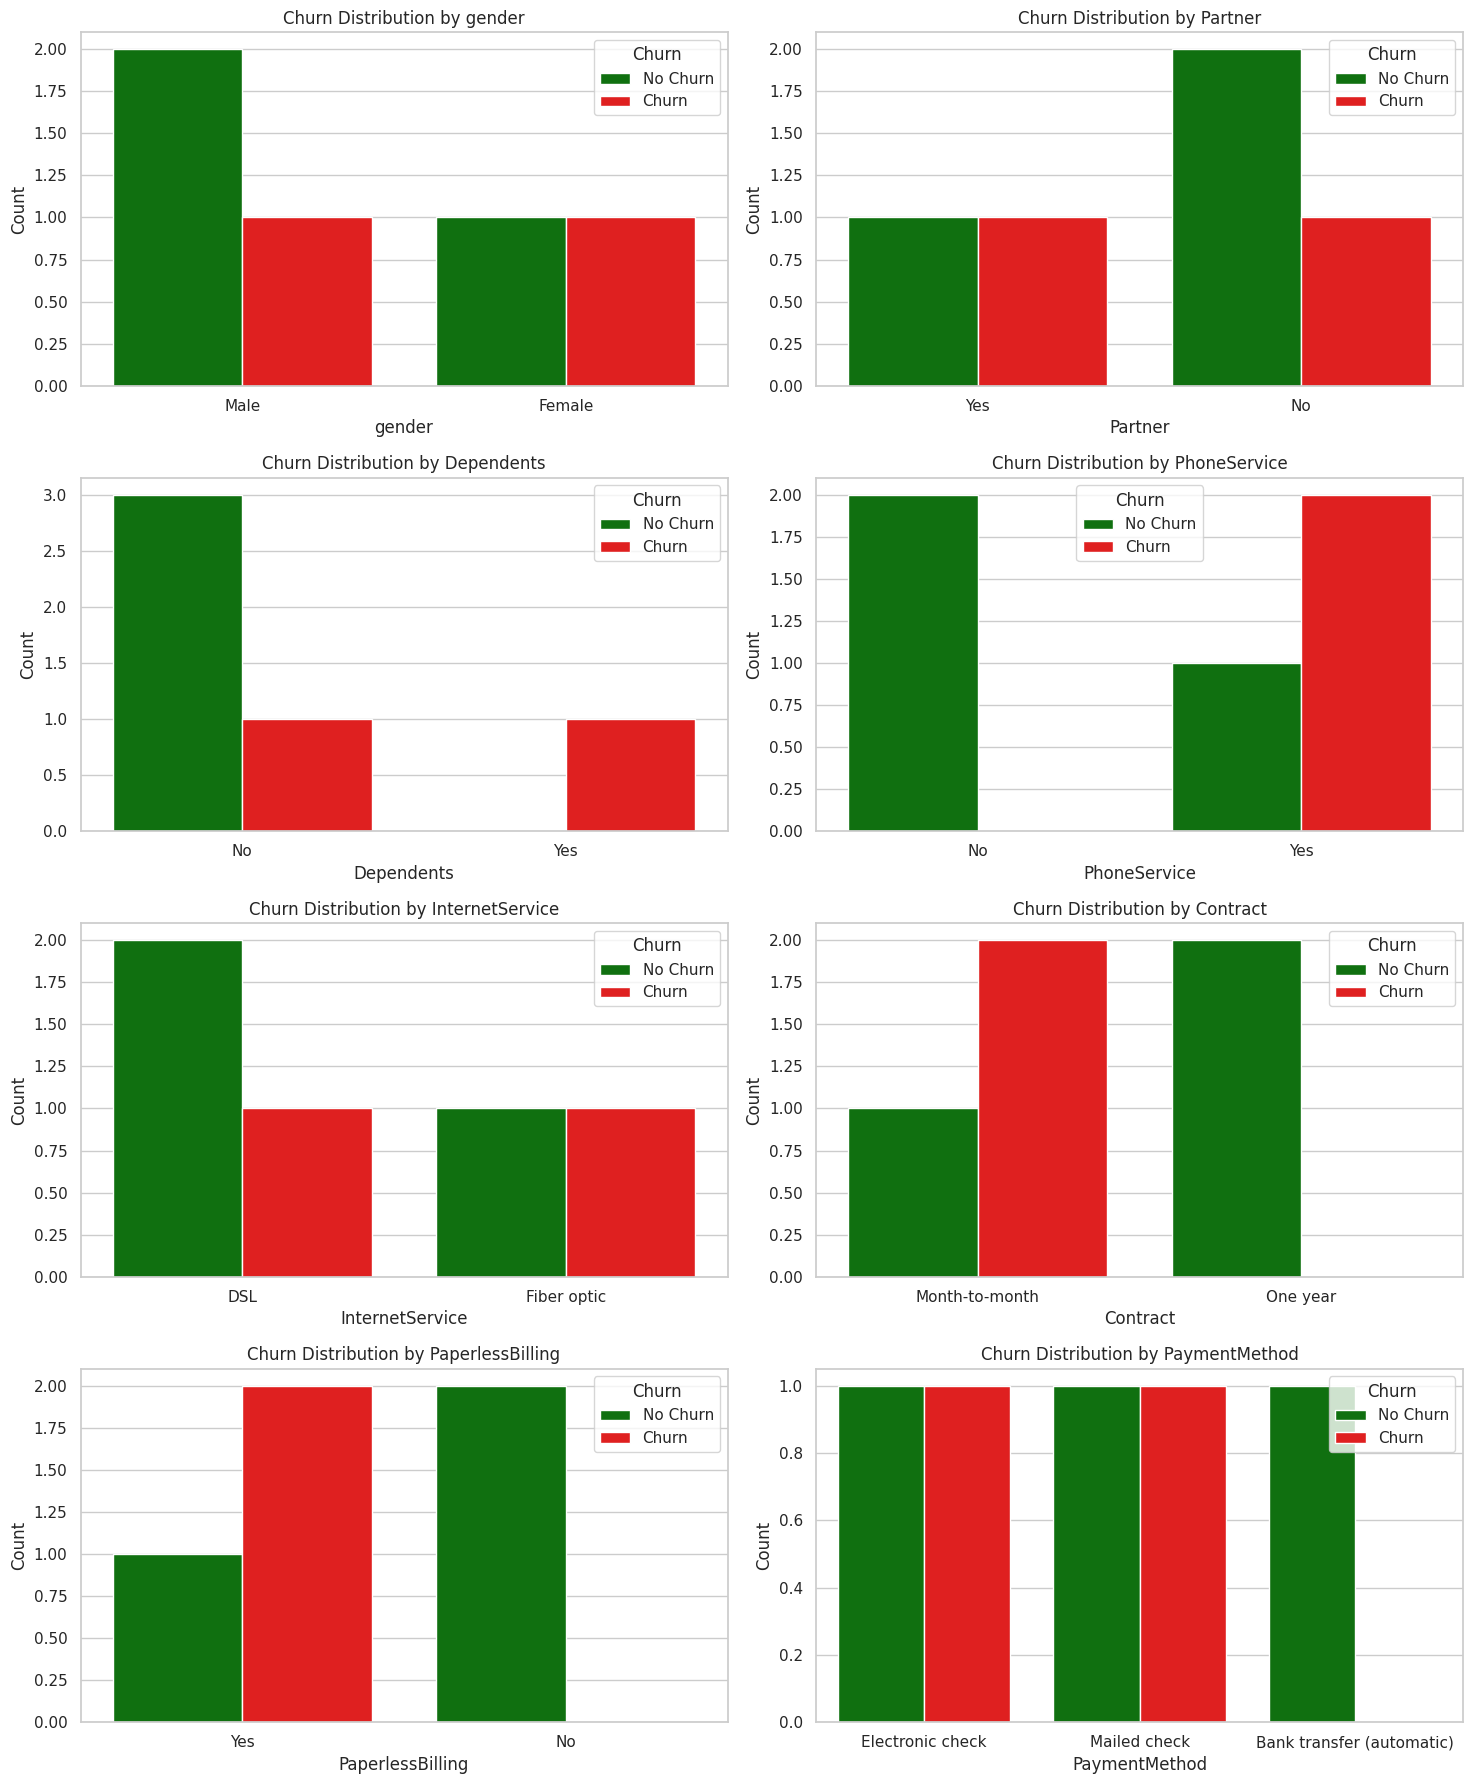

In [19]:
categorical_features = ['gender', 'Partner', 'Dependents', 'PhoneService', 'InternetService', 'Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(15, 18))
for i, feature in enumerate(categorical_features):
    plt.subplot(len(categorical_features) // 2 + len(categorical_features) % 2, 2, i + 1)
    sns.countplot(data=df, x=feature, hue='churn', palette={0: 'green', 1: 'red'})
    plt.title(f'Churn Distribution by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Count')
    plt.legend(title='Churn', labels=['No Churn', 'Churn'])
plt.tight_layout()
plt.show()

### 3. Churn by Numerical Features

Next, let's examine the distributions of numerical features such as `tenure`, `MonthlyCharges`, and `TotalCharges` for churned versus non-churned customers using box plots. These plots can help identify if churned customers tend to have significantly different values for these metrics.

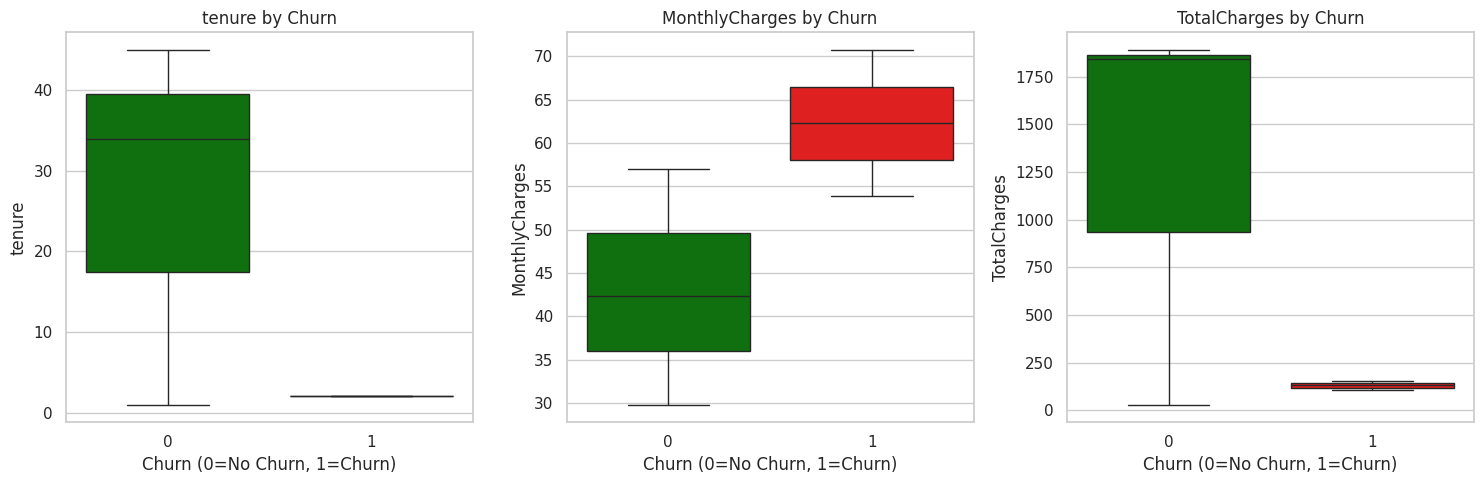

In [23]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(15, 5))
for i, feature in enumerate(numerical_features):
    plt.subplot(1, len(numerical_features), i + 1)
    # Fixed: Use integer keys for palette to match np.int64 values in 'churn'
    sns.boxplot(data=df, x='churn', y=feature, hue='churn', palette={0: 'green', 1: 'red'}, legend=False)
    plt.title(f'{feature} by Churn')
    plt.xlabel('Churn (0=No Churn, 1=Churn)')
    plt.ylabel(feature)
plt.tight_layout()
plt.show()

### 4. Correlation Heatmap

Finally, a correlation heatmap helps visualize the linear relationships between all numerical variables in the dataset. This includes the dummy variables created from categorical features and the target variable `churn` itself. Strong positive correlations are represented by colors closer to 1, strong negative correlations by colors closer to -1, and weak correlations by colors near 0.

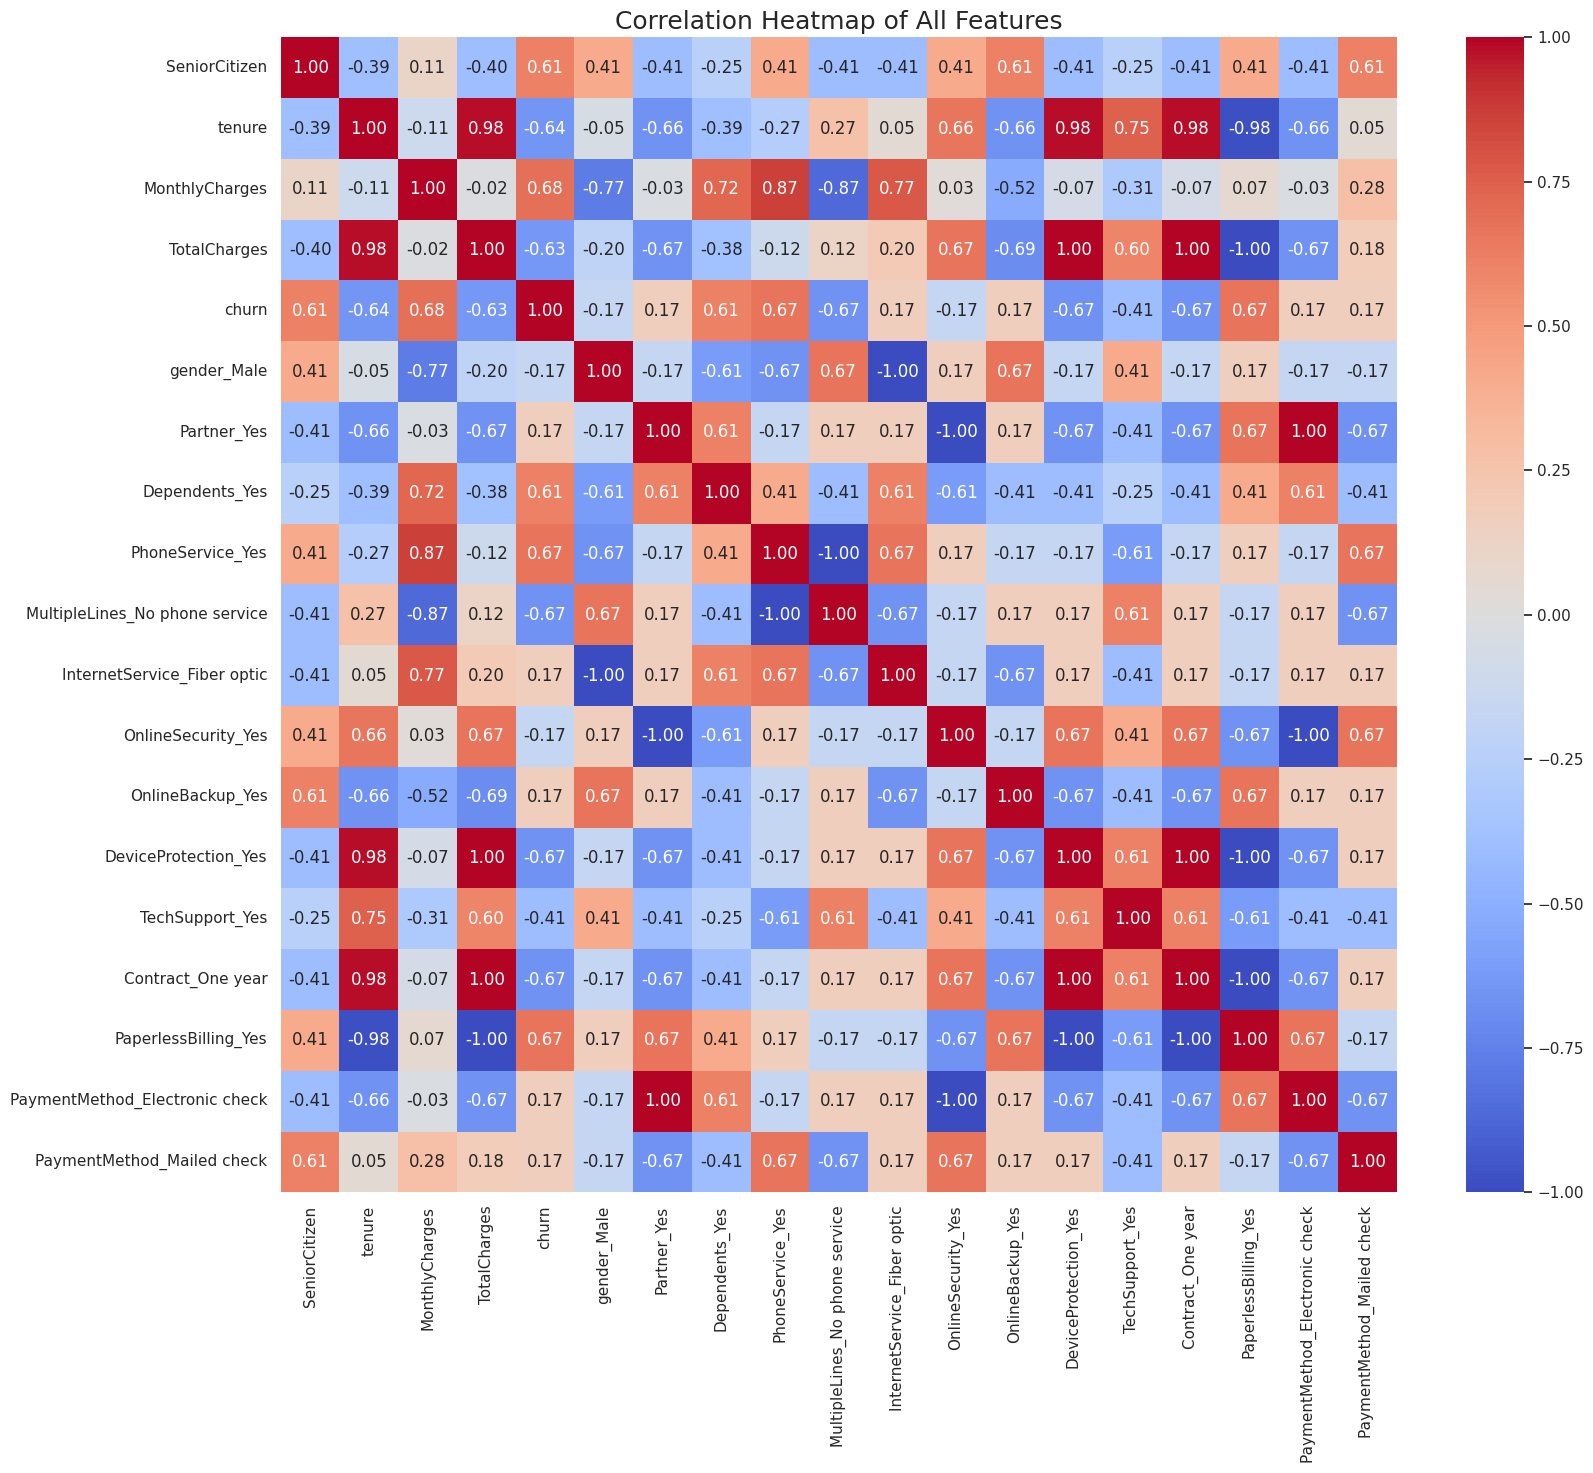

In [21]:
plt.figure(figsize=(18, 15))
sns.heatmap(df_processed.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of All Features', fontsize=18)
plt.show()

Dataset Shape: (9994, 21)
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
1       2  CA-2016-152156  11-08-2016  11-11-2016    Second Class    CG-12520   
2       3  CA-2016-138688  06-12-2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10-11-2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         Category Sub-Catego

/tmp/ipykernel_948/1787500551.py:49: UserWarning:

The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.



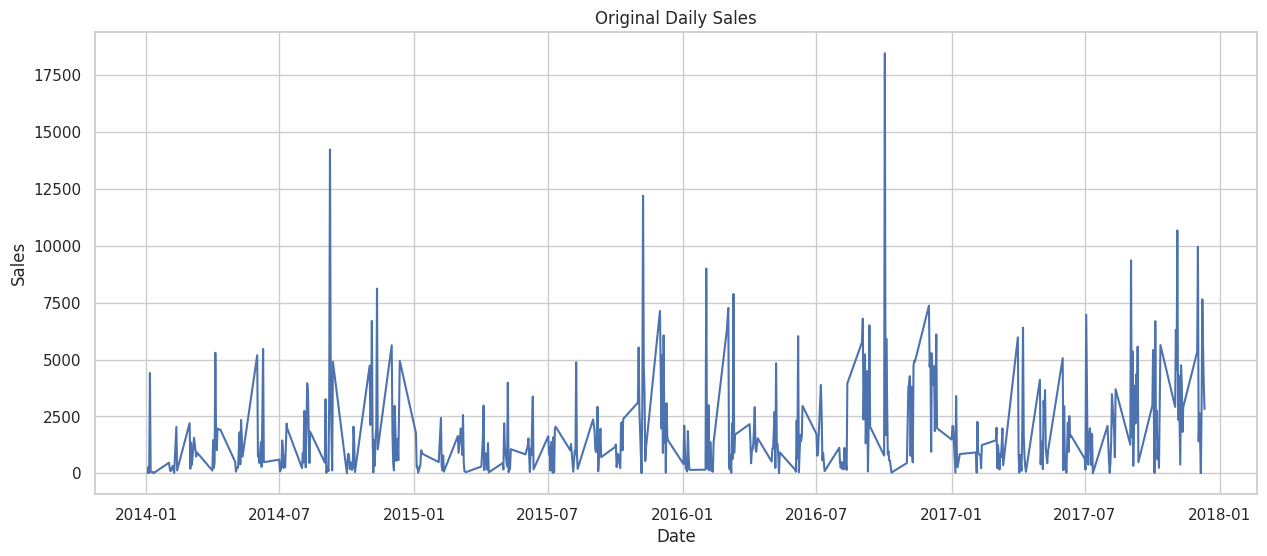


Holiday Sample
          ds           holiday
0 2016-01-01    New Year's Day
1 2016-05-30      Memorial Day
2 2016-07-04  Independence Day
3 2016-09-05         Labor Day
4 2016-11-24  Thanksgiving Day

Forecast Sample
            ds         yhat   yhat_lower   yhat_upper
843 2018-12-07  3871.029026  1396.303214  6297.103679
844 2018-12-08  4158.939252  1770.321442  6651.068317
845 2018-12-09  3906.836366  1561.447576  6300.361565
846 2018-12-10  3981.849205  1622.454456  6357.087965
847 2018-12-11  3355.868408   869.330457  5826.177744


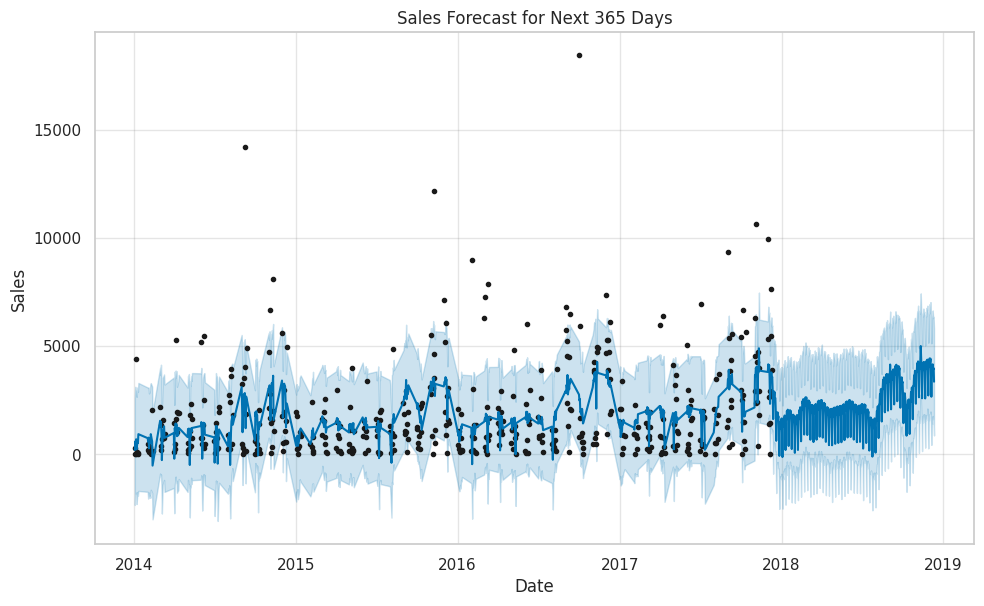

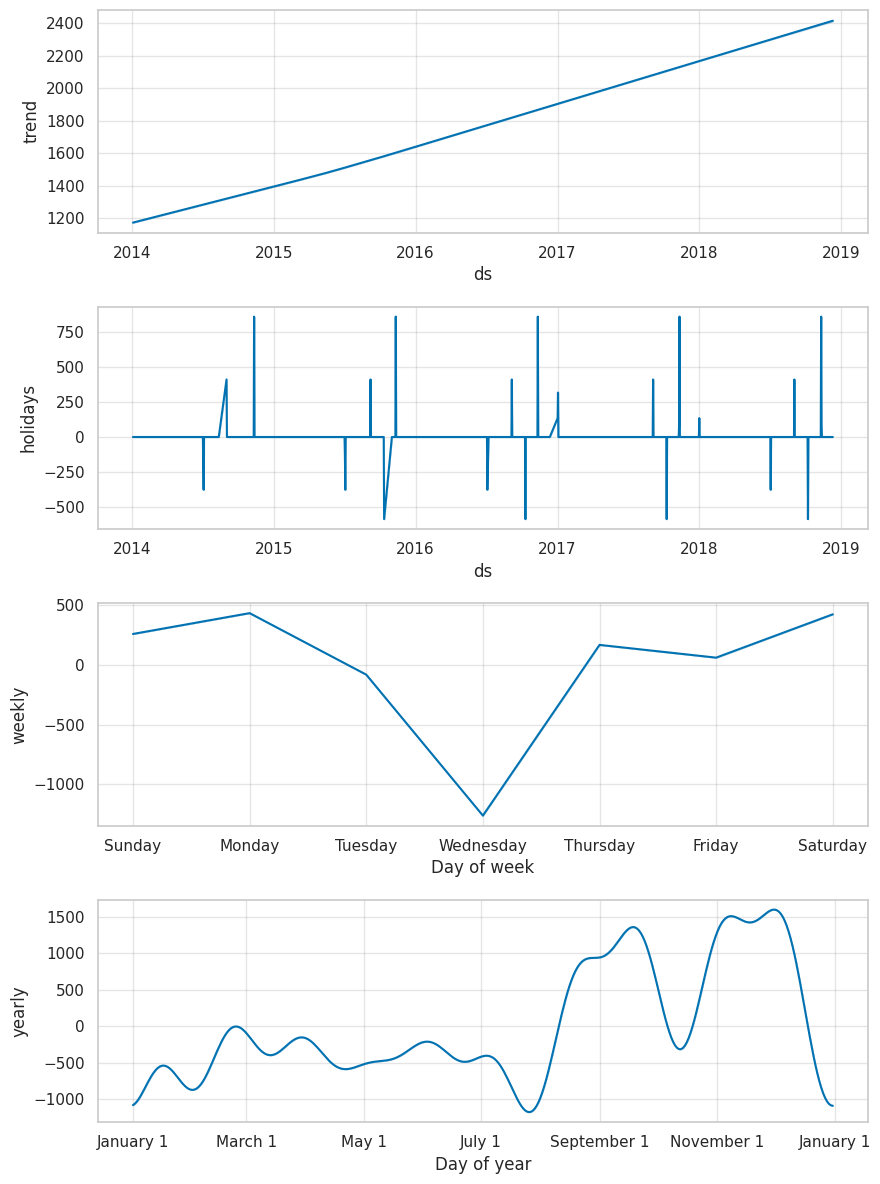

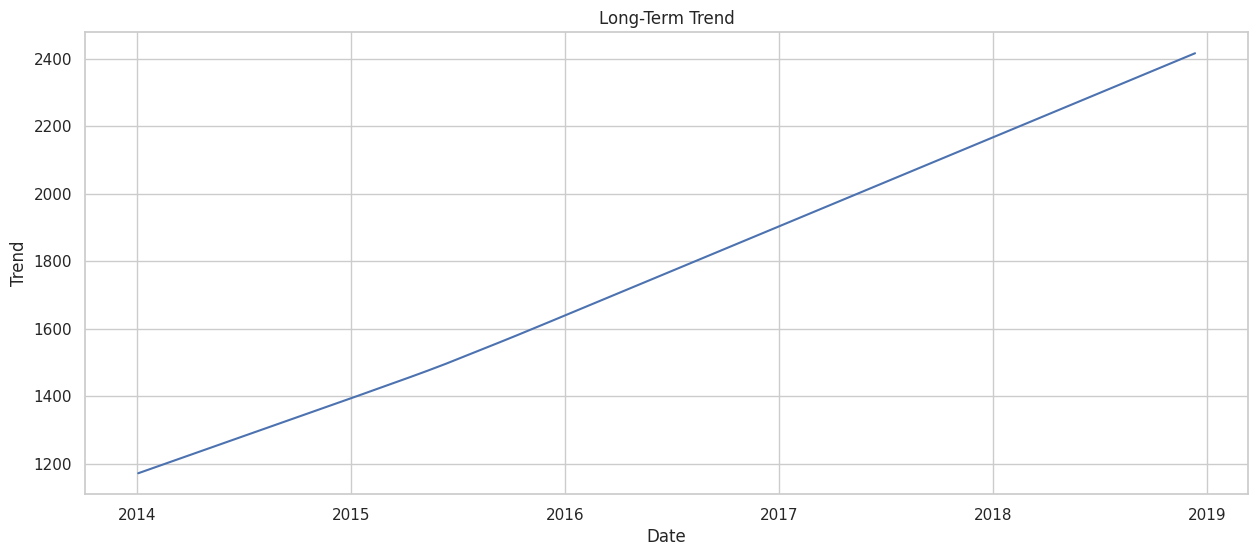

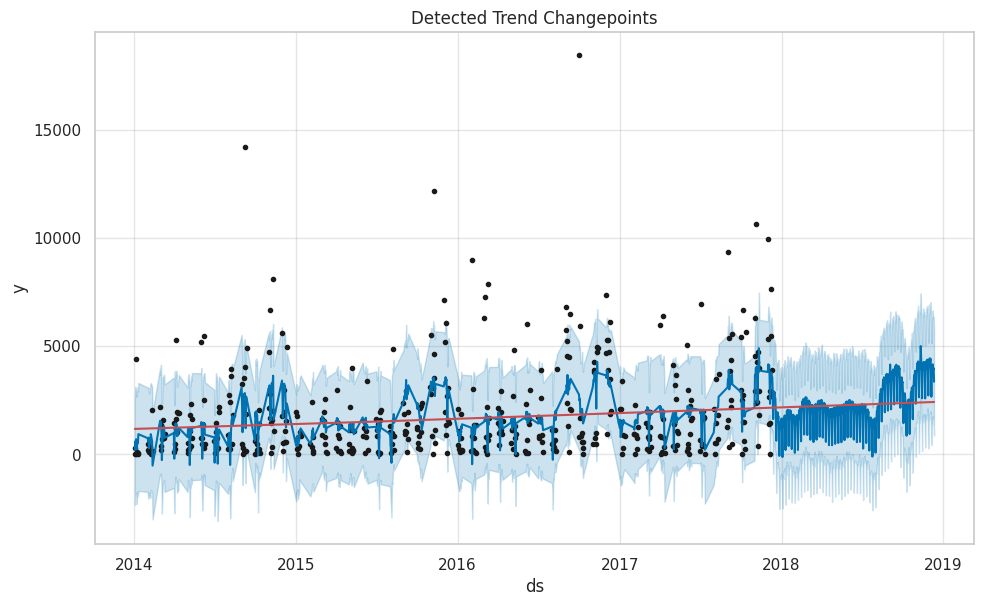

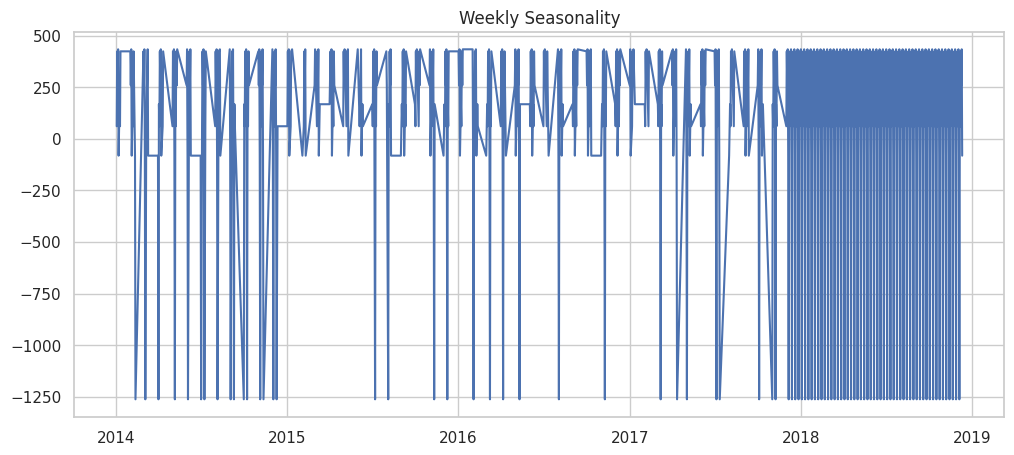

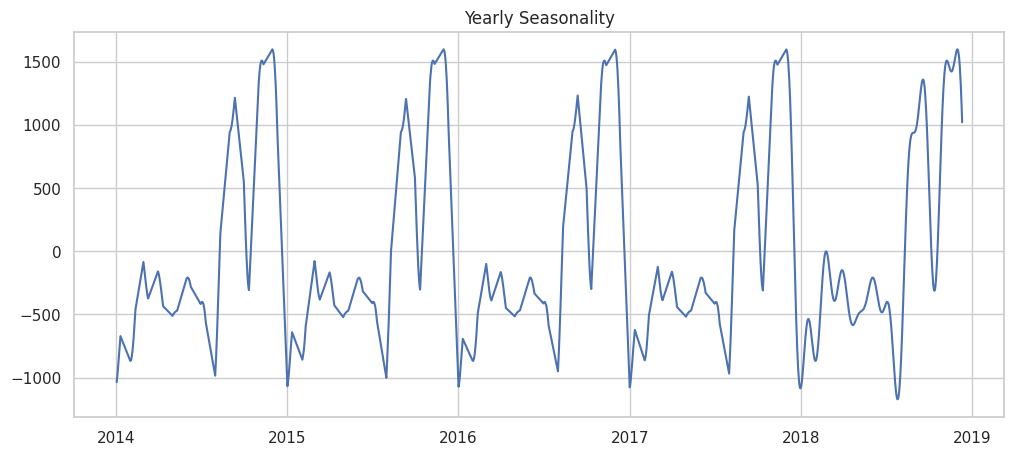


Holiday Impact
            ds  holidays  holidays_lower  holidays_upper
843 2018-12-07       0.0             0.0             0.0
844 2018-12-08       0.0             0.0             0.0
845 2018-12-09       0.0             0.0             0.0
846 2018-12-10       0.0             0.0             0.0
847 2018-12-11       0.0             0.0             0.0

Top Forecasted Sales Days
            ds         yhat
817 2018-11-11  5004.248113
470 2017-11-11  4902.074734
837 2018-12-01  4432.119838
839 2018-12-03  4420.349997
818 2018-11-12  4394.226263
832 2018-11-26  4375.631874
830 2018-11-24  4321.251262
816 2018-11-10  4320.456918
811 2018-11-05  4293.315334
345 2016-11-11  4272.182071
838 2018-12-02  4261.496888
825 2018-11-19  4259.514026
823 2018-11-17  4249.018291
809 2018-11-03  4209.809788
831 2018-11-25  4178.792765
835 2018-11-29  4164.300964
473 2017-12-02  4159.081162
844 2018-12-08  4158.939252
748 2018-09-03  4149.051860
762 2018-09-17  4140.069056

Next 30 Days Forecast
    

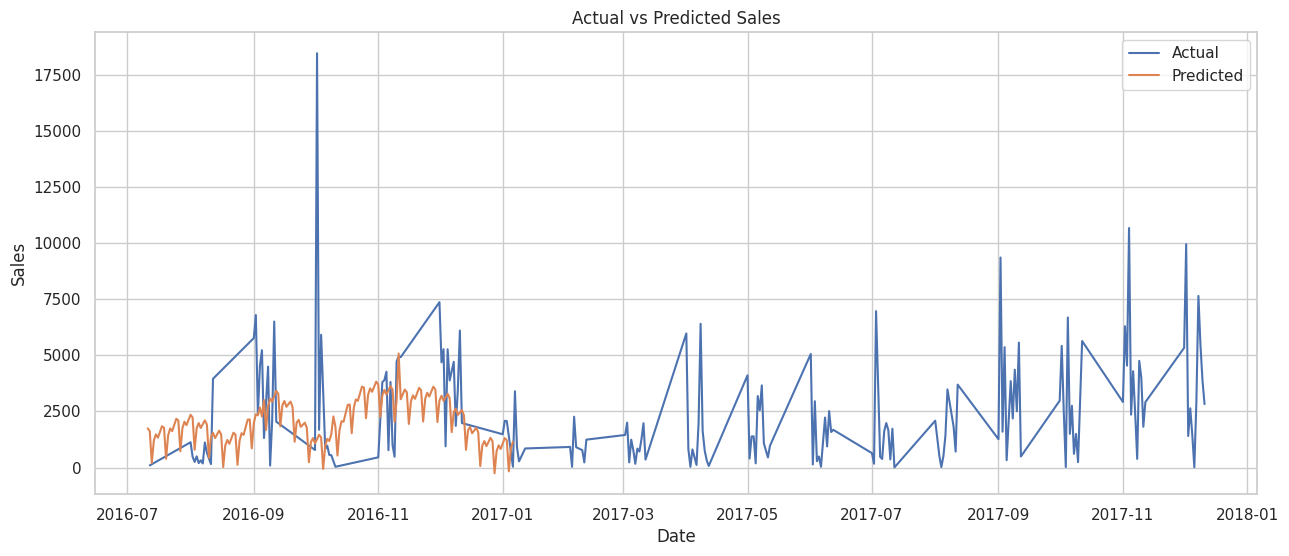


Running Interactive Forecast Plot...

Running Interactive Components Plot...

Forecast saved as:
Prophet_Sales_Forecast.csv

BUSINESS INSIGHTS

1. TREND
   - Observe whether sales are increasing or decreasing over time.

2. WEEKLY SEASONALITY
   - Identify highest and lowest sales weekdays.

3. YEARLY SEASONALITY
   - Identify peak sales months.

4. HOLIDAY EFFECT
   - Measure impact of holidays on sales.

5. FORECAST
   - Expected sales for next 365 days.

6. UNCERTAINTY
   - yhat_lower and yhat_upper provide confidence intervals.

7. RECOMMENDATIONS
   - Increase inventory before peak periods.
   - Schedule promotions during strong seasonal months.
   - Prepare staffing based on forecasted demand.



In [28]:
# ============================================================
# PROPHET TIME SERIES ANALYSIS ON SUPERSTORE SALES DATA
# Trend + Seasonality + Holidays + Forecast + Accuracy
# ============================================================

# Install libraries (Run once in Colab)
!pip install prophet holidays -q

# ============================================================
# IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.make_holidays import make_holidays_df
from prophet.plot import plot_plotly, plot_components_plotly

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

# ============================================================
# LOAD DATASET
# ============================================================

# To resolve the FileNotFoundError, please ensure 'SampleSuperstore.csv' is uploaded to your Colab environment.
# You can upload it by running the following lines in a separate cell, or manually drag-and-drop it into the files section.
# from google.colab import files
# uploaded = files.upload()
# for fn in uploaded.keys():
#   print('User uploaded file "{name}" with length {length} bytes'.format(name=fn, length=len(uploaded[fn])))

# Now, read the CSV file assuming it's in the /content/ directory after upload.
# Corrected filename based on available files in the environment
# Added encoding='latin1' to resolve UnicodeDecodeError
df = pd.read_csv('/content/Superstore-store analysis_Timeseries.csv', encoding='latin1')

print("Dataset Shape:", df.shape)
print(df.head())

# ============================================================
# DATA PREPROCESSING
# ============================================================

# Convert Order Date into datetime

df['Order Date'] = pd.to_datetime(
    df['Order Date'],
    errors='coerce'
    # infer_datetime_format is deprecated and removed as strict version is now default
)

# Remove missing dates
df = df.dropna(subset=['Order Date'])

# ============================================================
# AGGREGATE DAILY SALES
# ============================================================

daily_sales = (
    df.groupby('Order Date')['Sales']
    .sum()
    .reset_index()
)

daily_sales.columns = ['ds', 'y']

print("\nDaily Sales Data")
print(daily_sales.head())

# ============================================================
# VISUALIZE ORIGINAL SALES
# ============================================================

plt.figure(figsize=(15,6))
plt.plot(daily_sales['ds'], daily_sales['y'])
plt.title("Original Daily Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

# ============================================================
# CREATE US HOLIDAYS
# ============================================================

holidays = make_holidays_df(
    year_list=[2014,2015,2016,2017,2018,2019,2020],
    country='US'
)

print("\nHoliday Sample")
print(holidays.head())

# ============================================================
# BUILD PROPHET MODEL
# ============================================================

model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05
)

model.fit(daily_sales)

# ============================================================
# FORECAST NEXT 365 DAYS
# ============================================================

future = model.make_future_dataframe(
    periods=365,
    freq='D'
)

forecast = model.predict(future)

# ============================================================
# FORECAST OUTPUT
# ============================================================

print("\nForecast Sample")
print(
    forecast[
        ['ds','yhat','yhat_lower','yhat_upper']
    ].tail()
)

# ============================================================
# FORECAST PLOT
# ============================================================

fig1 = model.plot(forecast)
plt.title("Sales Forecast for Next 365 Days")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# ============================================================
# TREND + WEEKLY + YEARLY + HOLIDAY EFFECTS
# ============================================================

fig2 = model.plot_components(forecast)
plt.show()

# ============================================================
# TREND VISUALIZATION
# ============================================================

plt.figure(figsize=(15,6))
plt.plot(forecast['ds'], forecast['trend'])
plt.title("Long-Term Trend")
plt.xlabel("Date")
plt.ylabel("Trend")
plt.grid(True)
plt.show()

# ============================================================
# CHANGEPOINTS
# ============================================================

from prophet.plot import add_changepoints_to_plot

fig = model.plot(forecast)
a = add_changepoints_to_plot(fig.gca(), model, forecast)

plt.title("Detected Trend Changepoints")
plt.show()

# ============================================================
# WEEKLY SEASONALITY
# ============================================================

weekly = forecast[['ds','weekly']]

plt.figure(figsize=(12,5))
plt.plot(weekly['ds'], weekly['weekly'])
plt.title("Weekly Seasonality")
plt.show()

# ============================================================
# YEARLY SEASONALITY
# ============================================================

yearly = forecast[['ds','yearly']]

plt.figure(figsize=(12,5))
plt.plot(yearly['ds'], yearly['yearly'])
plt.title("Yearly Seasonality")
plt.show()

# ============================================================
# HOLIDAY EFFECT ANALYSIS
# ============================================================

holiday_columns = [
    col for col in forecast.columns
    if 'holiday' in col.lower()
]

if len(holiday_columns) > 0:
    print("\nHoliday Impact")
    print(
        forecast[['ds'] + holiday_columns]
        .tail()
    )
else:
    print("\nHoliday effect included in model.")

# ============================================================
# TOP 20 FORECASTED DAYS
# ============================================================

top_days = forecast[['ds','yhat']] \
    .sort_values('yhat', ascending=False) \
    .head(20)

print("\nTop Forecasted Sales Days")
print(top_days)

# ============================================================
# FORECAST FOR NEXT 30 DAYS
# ============================================================

next_30 = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(30)

print("\nNext 30 Days Forecast")
print(next_30)

# ============================================================
# MODEL ACCURACY CHECK
# ============================================================

train = daily_sales.iloc[:-180]
test = daily_sales.iloc[-180:]

accuracy_model = Prophet(
    holidays=holidays,
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

accuracy_model.fit(train)

future_test = accuracy_model.make_future_dataframe(
    periods=180,
    freq='D'
)

forecast_test = accuracy_model.predict(future_test)

predictions = forecast_test[['ds','yhat']].tail(180)

mae = mean_absolute_error(
    test['y'],
    predictions['yhat']
)

rmse = np.sqrt(
    mean_squared_error(
        test['y'],
        predictions['yhat']
    )
)

mape = np.mean(
    np.abs(
        (test['y'] - predictions['yhat'])
        / test['y']
    )
) * 100

print("\n==============================")
print("MODEL PERFORMANCE")
print("==============================")
print("MAE :", round(mae,2))
print("RMSE:", round(rmse,2))
print("MAPE:", round(mape,2), "%")

# ============================================================
# ACTUAL VS PREDICTED
# ============================================================

plt.figure(figsize=(15,6))

plt.plot(
    test['ds'],
    test['y'],
    label='Actual'
)

plt.plot(
    predictions['ds'],
    predictions['yhat'],
    label='Predicted'
)

plt.title("Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

# ============================================================
# INTERACTIVE PLOTS (COLAB)
# ============================================================

print("\nRunning Interactive Forecast Plot...")
plot_plotly(model, forecast)

print("\nRunning Interactive Components Plot...")
plot_components_plotly(model, forecast)

# ============================================================
# EXPORT FORECAST RESULTS
# ============================================================

forecast_output = forecast[
    ['ds','yhat','yhat_lower','yhat_upper']
]

forecast_output.to_csv(
    'Prophet_Sales_Forecast.csv',
    index=False
)

print("\nForecast saved as:")
print("Prophet_Sales_Forecast.csv")

# ============================================================
# BUSINESS INSIGHTS TO REPORT
# ============================================================

print("""
==============================
BUSINESS INSIGHTS
==============================

1. TREND
   - Observe whether sales are increasing or decreasing over time.

2. WEEKLY SEASONALITY
   - Identify highest and lowest sales weekdays.

3. YEARLY SEASONALITY
   - Identify peak sales months.

4. HOLIDAY EFFECT
   - Measure impact of holidays on sales.

5. FORECAST
   - Expected sales for next 365 days.

6. UNCERTAINTY
   - yhat_lower and yhat_upper provide confidence intervals.

7. RECOMMENDATIONS
   - Increase inventory before peak periods.
   - Schedule promotions during strong seasonal months.
   - Prepare staffing based on forecasted demand.
""")